In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/Brain-Tumor-Classification'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/data/raw', exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/models', exist_ok=True)
os.makedirs(f'{PROJECT_PATH}/results/figures', exist_ok=True)

print("done")

Mounted at /content/drive
done


In [3]:
import os
PROJECT_PATH = '/content/drive/MyDrive/Brain-Tumor-Classification'

zip_files = [f for f in os.listdir(f'{PROJECT_PATH}/data/raw') if f.endswith('.zip')]
print(zip_files)

['archive(4).zip']


In [4]:
import os
zip_path = f'{PROJECT_PATH}/data/raw/archive(4).zip'

size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"file size: {size_mb:.2f} MB")

file size: 157.04 MB


In [5]:
import zipfile

extract_path = f'{PROJECT_PATH}/data/raw'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("data has extracted successfully ")

data has extracted successfully


In [6]:
extract_path = f'{PROJECT_PATH}/data/raw'

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')

raw/
  archive(4).zip
  Testing/
    glioma/
    meningioma/
    notumor/
    pituitary/
  Training/
    glioma/
    meningioma/
    notumor/
    pituitary/


In [7]:
import os
import pandas as pd

base_path = f'{PROJECT_PATH}/data/raw'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
splits = ['Training', 'Testing']

counts = []

for split in splits:
    for cls in classes:
        folder_path = os.path.join(base_path, split, cls)
        num_images = len(os.listdir(folder_path))
        counts.append({'split': split, 'class': cls, 'count': num_images})

df_counts = pd.DataFrame(counts)
print(df_counts)

      split       class  count
0  Training      glioma   1400
1  Training  meningioma   1400
2  Training     notumor   1400
3  Training   pituitary   1400
4   Testing      glioma    400
5   Testing  meningioma    400
6   Testing     notumor    400
7   Testing   pituitary    400


/tmp/ipykernel_1363/2467835651.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_data, x='class', y='count', ax=axes[i], palette='viridis')
/tmp/ipykernel_1363/2467835651.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_data, x='class', y='count', ax=axes[i], palette='viridis')


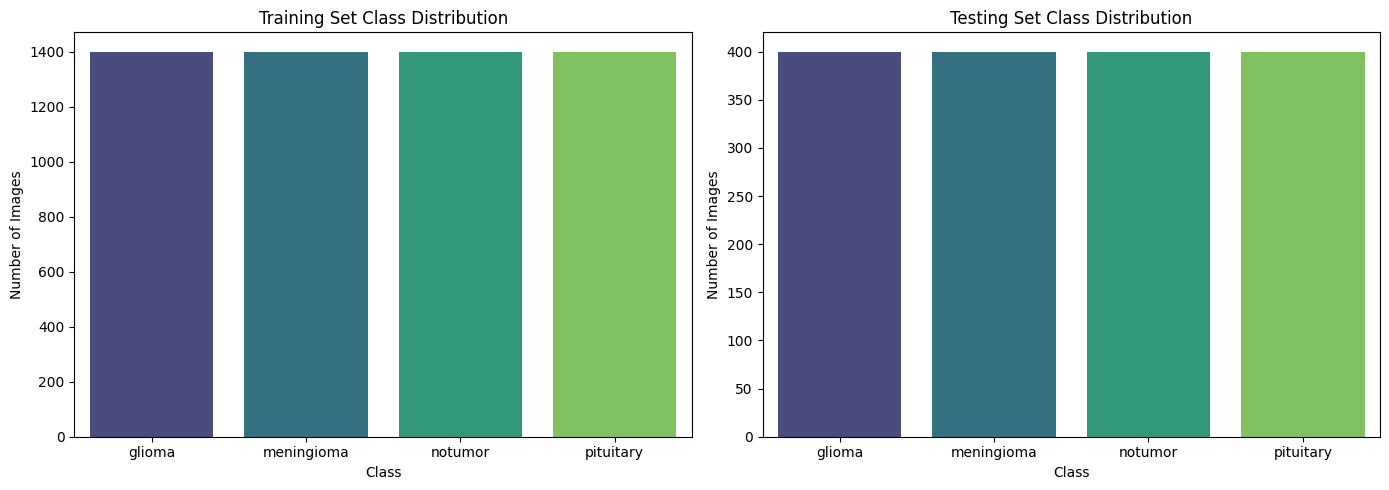

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, split in enumerate(splits):
    split_data = df_counts[df_counts['split'] == split]
    sns.barplot(data=split_data, x='class', y='count', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{split} Set Class Distribution')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Number of Images')

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/results/figures/class_distribution.png', dpi=150)
plt.show()

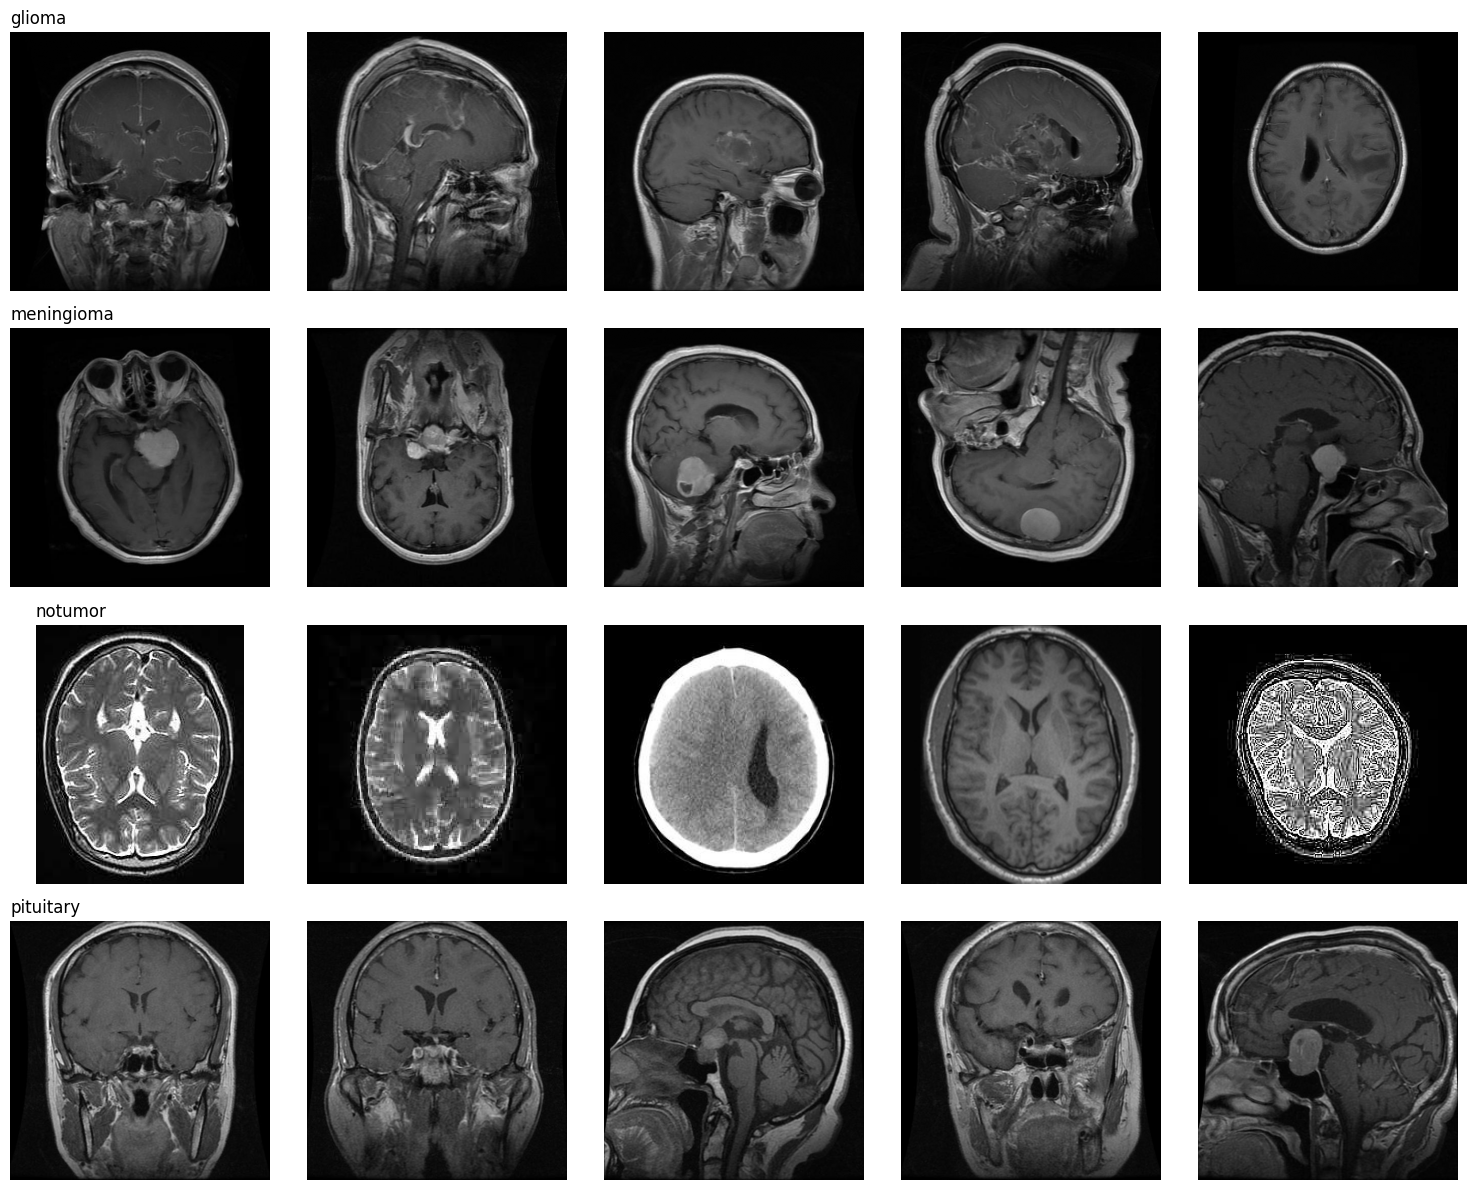

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = f'{PROJECT_PATH}/data/raw/Training'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

fig, axes = plt.subplots(len(classes), 5, figsize=(15, 12))

for i, cls in enumerate(classes):
    class_path = os.path.join(base_path, cls)
    image_files = os.listdir(class_path)[:5]

    for j, img_file in enumerate(image_files):
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=12)
    axes[i, 0].set_title(cls, fontsize=12, loc='left')

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/results/figures/sample_images_per_class.png', dpi=150)
plt.show()

In [10]:
from PIL import Image
import os
import pandas as pd

base_path = f'{PROJECT_PATH}/data/raw/Training'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

dimensions = []

for cls in classes:
    class_path = os.path.join(base_path, cls)
    image_files = os.listdir(class_path)

    for img_file in image_files[:100]:  # sample 100 images per class for speed
        img_path = os.path.join(class_path, img_file)
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode  # 'L' for grayscale, 'RGB' for color
            dimensions.append({'class': cls, 'width': width, 'height': height, 'mode': mode})

df_dims = pd.DataFrame(dimensions)
print(df_dims.describe())
print("\nUnique image modes found:")
print(df_dims['mode'].value_counts())
print("\nUnique dimensions found:")
print(df_dims.groupby(['width', 'height']).size().sort_values(ascending=False).head(10))

            width      height
count  400.000000  400.000000
mean   459.905000  461.532500
std    115.549601  109.754266
min    150.000000  183.000000
25%    512.000000  512.000000
50%    512.000000  512.000000
75%    512.000000  512.000000
max    900.000000  741.000000

Unique image modes found:
mode
RGB    252
L      148
Name: count, dtype: int64

Unique dimensions found:
width  height
512    512       296
225    225        23
630    630         6
236    236         5
468    444         4
192    192         4
201    251         3
218    231         3
393    400         3
442    442         3
dtype: int64


In [11]:
from PIL import Image
import os

base_path = f'{PROJECT_PATH}/data/raw'
splits = ['Training', 'Testing']
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

corrupted_files = []
total_checked = 0

for split in splits:
    for cls in classes:
        folder_path = os.path.join(base_path, split, cls)
        for img_file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_file)
            total_checked += 1
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception as e:
                corrupted_files.append(img_path)

print(f"Total images checked: {total_checked}")
print(f"Corrupted images found: {len(corrupted_files)}")
if corrupted_files:
    print("Corrupted file paths:")
    for f in corrupted_files:
        print(f)

Total images checked: 7200
Corrupted images found: 0


In [12]:
eda_summary = {
    'total_images': 7200,
    'training_images': 5600,
    'testing_images': 1600,
    'classes': ['glioma', 'meningioma', 'notumor', 'pituitary'],
    'images_per_class_training': 1400,
    'images_per_class_testing': 400,
    'corrupted_images': 0,
    'dominant_dimension': '512x512',
    'mixed_color_modes': True,
    'rgb_count_sample': 252,
    'grayscale_count_sample': 148
}

import json
with open(f'{PROJECT_PATH}/results/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=4)

print("EDA summary saved.")

EDA summary saved.
